In [1]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
# import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm

ModuleNotFoundError: No module named 'torch'

In [ ]:
# 概率比较部分
from scipy.special import gammaln
# import torch.distributions as dist

# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation

import os
import glob
import re

In [2]:
from importlib import reload  
  
reload(DE)
from DE import DESimulation

NameError: name 'DE' is not defined

In [4]:
data = np.load("./sim_config/cevns_sim.npz")
data_original = np.load("data/e_spectrum_relics.npz")

In [8]:
# 创建一个字典来复制数据
new_data_dict = {key: data[key] for key in data.files}

# 修改特定的数据, 按照100倍曝光量模拟3电子及以上事件
new_data_dict['CEvNS'] = data_original['CEvNS']* 32 

new_data_dict['CEvNS'][:3] = 1

print(new_data_dict['CEvNS'])

np.savez('sim_config/cevns_sim_3e.npz',**new_data_dict)

[1.00000000e+00 1.00000000e+00 1.00000000e+00 2.27016221e+04
 9.79127136e+03 4.44068941e+03 2.03188205e+03 9.19509321e+02
 4.07237142e+02 1.75417887e+02 7.32063127e+01 2.95266494e+01
 1.14930982e+01 4.31395124e+00 1.56094737e+00 5.44473810e-01
 1.83122688e-01 5.94095600e-02 1.86013399e-02 5.62429498e-03]


In [12]:
muon_track_file_load_once = 5
param = 0

DE_sim = DESimulation('sim_config/CEvNS_3-10_demo.yaml')

muon_file_list = []
for i in range(muon_track_file_load_once):
    # print(i)
    file_index = param * muon_track_file_load_once + i
    filename = DE_sim.muon_track_file + \
        "muon_track." + str(file_index) + ('.npy')
    # print(filename)
    muon_file_list.append(filename)

In [13]:
DE_sim.generate_muon_points(muon_file_list)
print(" \n Sim muon last time:{}h \n".format(DE_sim.time_range/3600))
print(DE_sim.cevns_e_spectrum)
print(DE_sim.cevns_e_num)

DE_sim.generate_CEVNS_points()
DE_sim.generate_CEVNS_pattern()

DE_sim.CEVNS_position_recon()

DE_sim.generate_CEVNS_recon_pattern()
DE_sim.CEVNS_sp_cor()


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 276.05it/s]


First muon track file: ./muon_track/muon_track.0.npy
Last muon track file: ./muon_track/muon_track.4.npy
Number of muon events: 15619
merged_muon_array data type: [('eventId', '<i4'), ('type', 'i1'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]
dense_muon_points data type:  [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]
 
 Sim muon last time:0.4232520325203252h 

[    1     1 22701  9791  4440  2031   919   407   175    73]
[ 1  2  3  4  5  6  7  8  9 10]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 730/730 [00:00<00:00, 146506.62it/s]


Start pos recon for event size:  1
(1, 64)
1
Start pos recon for event size:  2
(1, 64)
1
Start pos recon for event size:  3
(22701, 64)
22701
Start pos recon for event size:  4
(9791, 64)
9791
Start pos recon for event size:  5
(4440, 64)
4440
Start pos recon for event size:  6
(2031, 64)
2031
Start pos recon for event size:  7
(919, 64)
919
Start pos recon for event size:  8
(407, 64)
407
Start pos recon for event size:  9
(175, 64)
175
Start pos recon for event size:  10
(73, 64)
73
last_muon_id.shape:  (1,)
last_muon_id[-10:]:  [13776]
0
0 1


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2067.18it/s]


...

平均电子数：  8.011347842830444
last_muon_id.shape:  (175,)
last_muon_id[-10:]:  [14431 14651 14990 15044 15094 15163 15217 15271 15384 15584]
0
0 175


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 175/175 [00:00<00:00, 20432.11it/s]


平均电子数：  8.984716871136815
last_muon_id.shape:  (73,)
last_muon_id[-10:]:  [13861 13942 14066 14100 14172 14880 15176 15249 15299 15350]
0
0 73


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:00<00:00, 19112.62it/s]

平均电子数：  9.96500169038339


画cevns重建前后pattern
====

In [16]:
len(DE_sim.cevns_points)

10

In [17]:
DE_sim.cevns_points[3]["pe_by_area"][0]

array([2.1814997 , 2.48770343, 0.        , 0.        , 1.13763418,
       0.75166126, 0.26099555, 8.69980533, 0.692205  , 0.        ,
       0.        , 0.        , 0.76795975, 0.        , 0.        ,
       0.57313434, 0.        , 0.        , 0.        , 0.        ,
       0.70142073, 1.42114769, 0.        , 0.90273327, 0.64007253,
       0.        , 0.        , 0.        , 0.88708078, 0.        ,
       0.        , 0.        , 0.        , 0.        , 1.50702286,
       0.        , 0.        , 0.67047148, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.9102168 , 3.42769733,
       1.90048852, 2.20193726, 0.61160588, 0.        , 1.48764235,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       1.06117312, 0.        , 0.67537157, 2.02753193, 7.46265974,
       2.41989705, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 2.07529832, 0.        ,
       2.31061073, 0.92795569, 0.        , 0.        , 2.61459

In [58]:
def pattern_plot(phe_pmt, electron = [] , pos_recons = [], pmt_info = DE_sim.pmt_info,title = "",savefig = False):
    artists = list()
    # cmap = mpl.cm.viridis
    # 定义灰度色图
    cmap = cm.get_cmap("YlOrRd")
    norm = mpl.colors.LogNorm(vmin=1, vmax=phe_pmt.max(), clip=True)
    colors = ['blue', 'green', 'yellow','red']  # 自定义颜色列表
    #norm = mpl.colors.LogNorm(vmin=1, vmax=1000, clip=True)
    fig = plt.figure(figsize=(7, 6))

    # grid = ImageGrid(fig, 111, (1,1), cbar_mode='single', axes_pad=0.1, cbar_pad=0.2)
    grid = ImageGrid(fig, 111, (1,1))

    # PMT plot
    # for pmt_id in range(64):
    #     pmt = pmt_info[pmt_id]
    #     pe_value = phe_pmt[pmt_id]
    #     # print(str(round(pe_value,2)))
    #     # grid[0].text(pmt['x'], pmt['y'], str(pmt['ChannelID']), ha='center', va='center')
    #     grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
    #     # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc=cmap(norm(phe_pmt[pmt_id])),alpha = 0.86))
    #     # grid[0].add_patch(artists[pmt['ChannelID']])
    for pmt_id in range(64):
        pmt = pmt_info[pmt_id]
        pe_value = phe_pmt[pmt_id]
        # 检查 PMT 值并设定颜色
        # if phe_pmt[pmt_id] < 0.5:
        #     pmt_color = 'white'  # 小于0.1的通道颜色为白色
        # else:
        pmt_color = cmap(norm(phe_pmt[pmt_id]))
            # 绘制alpha为1的白色边框
        grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
        border = Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc='none', ec='black', lw=1, alpha=1)    
        grid[0].add_patch(border)

        # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
        #                angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
        #                alpha=(phe_pmt[i][pmt_id] / vmax)**0))

        artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
                       angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
                       alpha=1))
        grid[0].add_patch(artists[pmt['ChannelID']])
    # event plot
    if len(electron)>0:
        grid[0].plot(electron['xd']/10, electron['yd']/10, 'o', color = 'cyan', markersize=12 ,label = 'DE Position')
  
    # recon_pos plot
    if len(pos_recons)>0:
        grid[0].plot(pos_recons['xd']/10, pos_recons['yd']/10, 'b*', markersize=12, label = 'Recon Position')
        
    # muon_point_plot
    # if muon_id_list is not None:
        # for i, muon_id in enumerate(muon_id_list):
            # color = colors[i % len(colors)]  # 从颜色列表中选择颜色
            # grid[0].plot(dense_muon_points[dense_muon_points['eventId'] == muon_id]['xd']/10, dense_muon_points[dense_muon_points['eventId'] == muon_id]['yd']/10, 'o', label="muon id: {}".format(muon_id), markersize=2, alpha=0.5, color=color)
            
    # TPC outline
    angle = np.arange(13)*np.pi/6
    outer_r = 14/np.cos(np.pi/12)
    grid[0].plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=3)

    # Colorbar
    # grid.cbar_axes[0].colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm))

    # Other settings
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    # grid[0].legend(bbox_to_anchor=(1.2, 0), loc=3, borderaxespad=0, prop={'size': 7})
    # grid[0].set_title(title)
    if savefig == True: 
        plt.savefig(title+".png")
    plt.show()
    return 0

def position_plot(phe_pmt, electron = [] , pos_recons = [], pmt_info = DE_sim.pmt_info,title = "",savefig = False):
    artists = list()
    # cmap = mpl.cm.viridis
    # 定义灰度色图
    cmap = cm.get_cmap("YlOrRd")
    norm = mpl.colors.LogNorm(vmin=1, vmax=phe_pmt.max(), clip=True)
    colors = ['blue', 'green', 'yellow','red']  # 自定义颜色列表
    #norm = mpl.colors.LogNorm(vmin=1, vmax=1000, clip=True)
    fig = plt.figure(figsize=(7, 6))

    # grid = ImageGrid(fig, 111, (1,1), cbar_mode='single', axes_pad=0.1, cbar_pad=0.2)
    grid = ImageGrid(fig, 111, (1,1))

    # PMT plot
    # for pmt_id in range(64):
    #     pmt = pmt_info[pmt_id]
    #     pe_value = phe_pmt[pmt_id]
    #     # print(str(round(pe_value,2)))
    #     # grid[0].text(pmt['x'], pmt['y'], str(pmt['ChannelID']), ha='center', va='center')
    #     grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
    #     # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc=cmap(norm(phe_pmt[pmt_id])),alpha = 0.86))
    #     # grid[0].add_patch(artists[pmt['ChannelID']])
    for pmt_id in range(64):
        pmt = pmt_info[pmt_id]
        pe_value = phe_pmt[pmt_id]
        # 检查 PMT 值并设定颜色
        # if phe_pmt[pmt_id] < 0.5:
        #     pmt_color = 'white'  # 小于0.1的通道颜色为白色
        # else:
        pmt_color = 'white'
            # 绘制alpha为1的白色边框
        # grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
        border = Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc='none', ec='black', lw=1, alpha=1)    
        grid[0].add_patch(border)

        # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
        #                angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
        #                alpha=(phe_pmt[i][pmt_id] / vmax)**0))

        artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
                       angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
                       alpha=1))
        grid[0].add_patch(artists[pmt['ChannelID']])
    # event plot
    if len(electron)>0:
        grid[0].plot(electron['xd']/10, electron['yd']/10, 'ro', markersize=12 ,label = 'DE Position')
  
    # recon_pos plot
    if len(pos_recons)>0:
        grid[0].plot(pos_recons['xd']/10, pos_recons['yd']/10, 'b*', markersize=12, label = 'Recon Position')
        
    # muon_point_plot
    # if muon_id_list is not None:
        # for i, muon_id in enumerate(muon_id_list):
            # color = colors[i % len(colors)]  # 从颜色列表中选择颜色
            # grid[0].plot(dense_muon_points[dense_muon_points['eventId'] == muon_id]['xd']/10, dense_muon_points[dense_muon_points['eventId'] == muon_id]['yd']/10, 'o', label="muon id: {}".format(muon_id), markersize=2, alpha=0.5, color=color)
            
    # TPC outline
    angle = np.arange(13)*np.pi/6
    outer_r = 14/np.cos(np.pi/12)
    grid[0].plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=3)

    # Colorbar
    # grid.cbar_axes[0].colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm))

    # Other settings
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    # grid[0].legend(bbox_to_anchor=(1.2, 0), loc=3, borderaxespad=0, prop={'size': 7})
    # grid[0].set_title(title)
    if savefig == True: 
        plt.savefig(title+".png")
    plt.show()
    return 0

/tmp/ipykernel_1963554/400806110.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("YlOrRd")


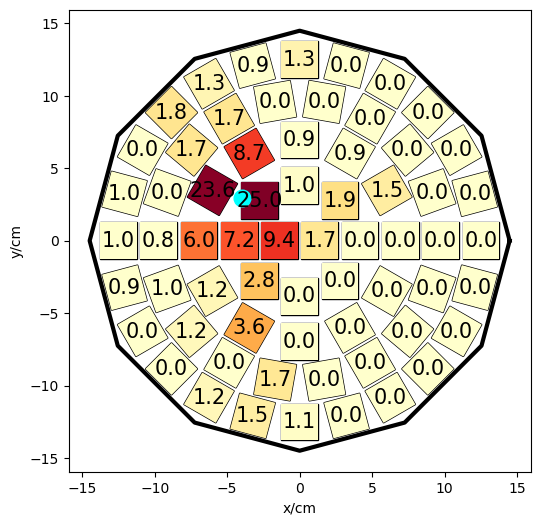

/tmp/ipykernel_1963554/400806110.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("YlOrRd")


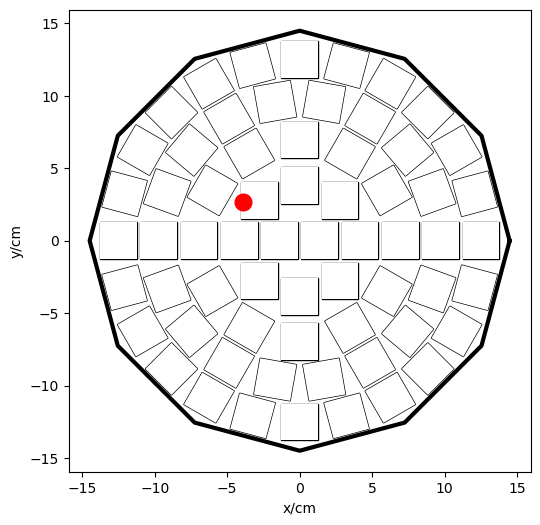

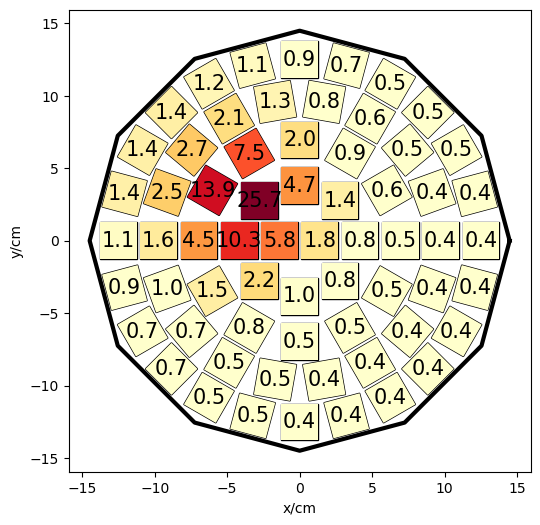

0

In [59]:
pattern_plot(DE_sim.cevns_points[4]["pe_by_area"][2], DE_sim.cevns_points[4]["pos_original"][2], title = 'figure/CEvNS_pattern', savefig = True)
position_plot(DE_sim.cevns_points[4]["pe_by_area"][2], DE_sim.cevns_points[4]["pos_recon"][2], title = 'figure/CEvNS_pos', savefig = True)
pattern_plot(DE_sim.cevns_points[4]["recons_light_pattern"][2], title = 'figure/CEvNS_pattern_recon', savefig = True)

延迟电子Pile up事件模拟
=====

In [43]:
DE_sim.generate_DE_points()
# DE_sim.generate_Pile_UP_2e()
DE_sim.generate_Pile_UP_3e()
DE_sim.generate_Pile_UP_multi_e()
DE_sim.generate_DE_pattern_linear()
DE_sim.DE_position_recon()
DE_sim.generate_DE_recon_pattern()
DE_sim.DE_sp_cor()

Start sorting DE's time
Finish sorting DE's time


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 8924.05it/s]


Start pos recon for event size:  3
(25025, 64)
25025
Start pos recon for event size:  4
(3434, 64)
3434
Start pos recon for event size:  5
(299, 64)
299
Start pos recon for event size:  6
(26, 64)
26
Start pos recon for event size:  7
(1, 64)
1
last_muon_id.shape:  (25025,)
last_muon_id[-10:]:  [15616 15616 15616 15616 15618 15618 15618 15618 15618 15618]
0
0 25025


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25025/25025 [00:01<00:00, 14013.87it/s]


平均电子数：  3.447162543447297
last_muon_id.shape:  (3434,)
last_muon_id[-10:]:  [15562 15562 15565 15566 15576 15586 15586 15601 15614 15614]
0
0 3434


...

平均电子数：  4.882117749402759
last_muon_id.shape:  (26,)
last_muon_id[-10:]:  [ 7188  9612 10016 10888 11335 12077 12178 13546 15146 15392]
0
0 26


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 14405.80it/s]


平均电子数：  6.0871567305112375
last_muon_id.shape:  (1,)
last_muon_id[-10:]:  [11304]
0
0 1


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1752.01it/s]

平均电子数：  7.30228170706216


In [45]:
DE_sim.pile_up_e_num

[3, 4, 5, 6, 7]

In [51]:
DE_sim.pile_up_recons_light_pattern[1][0]

array([ 0.58189002,  0.80895485,  0.73837668,  0.56177714,  1.93763843,
        5.31001892,  1.76366453,  0.40244188,  0.3438891 ,  0.37220237,
        0.29902762,  0.39045842,  0.50576488,  0.66370495,  0.97418533,
        1.4400131 ,  1.88834957,  1.5727144 ,  1.05167412,  0.72254912,
        0.5133687 ,  0.45063811,  0.33537431,  0.28762164,  0.24960212,
        0.24733154,  0.21989131,  0.22308963,  0.20368878,  0.21390163,
        0.21666834,  0.24086968,  0.24547716,  0.28528117,  0.3275509 ,
        0.43771967,  0.70802421,  1.62637183,  4.60292256,  5.31584977,
        1.90542061,  0.80668022,  0.47066635,  0.31370025,  0.28215294,
        0.22794116,  0.22090711,  0.21342695,  0.21465748,  0.23163012,
        0.22886431,  0.24665825,  0.39330988,  0.82911509,  3.57899408,
       18.8720106 ,  4.36414591,  0.89837296,  0.41217952,  0.28836136,
        0.25036603,  0.26154985,  0.23916734,  0.27844683,  0.77257368,
        0.75501382,  0.74046996,  0.71116551,  0.76479824,  0.81

/tmp/ipykernel_1963554/400806110.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("YlOrRd")


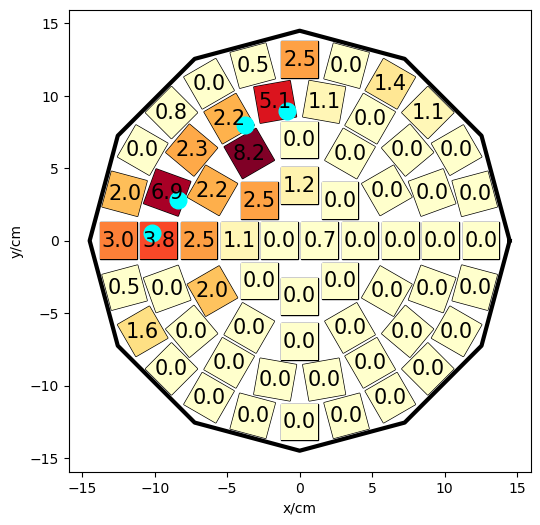

/tmp/ipykernel_1963554/400806110.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("YlOrRd")


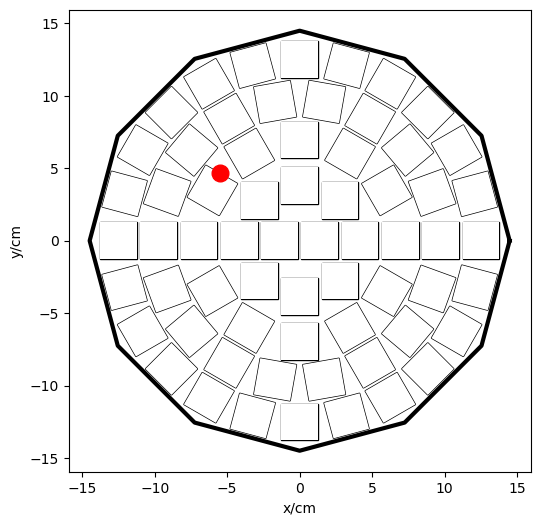

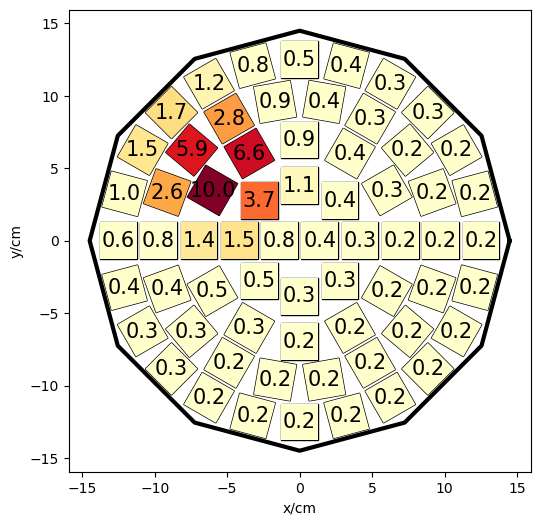

0

In [60]:
pattern_plot(DE_sim.pile_up_pe_by_area[1][1], 
             DE_sim.pile_up_result[1][1], 
             title = 'figure/DE_pattern' , savefig = True)

position_plot(DE_sim.pile_up_pe_by_area[1][1], DE_sim.pile_up_pos_recon[1][1], title = 'figure/DE_pos', savefig = True)

pattern_plot(DE_sim.pile_up_recons_light_pattern[1][1],  
             title = 'figure/DE_recon_pattern', savefig = True)
